## HOUSE PRICE PREDICTION

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df=pd.read_csv('../data/house_price_regression_dataset.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [41]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [42]:
df.shape

(1000, 8)

In [43]:
df.size

8000

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [45]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [46]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [47]:
df['Num_Bedrooms'].value_counts()

Num_Bedrooms
2    215
5    205
1    201
4    197
3    182
Name: count, dtype: int64

In [48]:
df['Neighborhood_Quality'].value_counts()

Neighborhood_Quality
10    123
5     109
2     105
7     102
6     101
4      99
8      97
1      91
9      88
3      85
Name: count, dtype: int64

In [49]:
df['Garage_Size'].value_counts()

Garage_Size
2    343
1    336
0    321
Name: count, dtype: int64

In [50]:
df.corr()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
Square_Footage,1.000000,-0.043564,-0.031584,-0.022392,0.089479,0.030593,-0.008357,0.991261
Num_Bedrooms,-0.043564,1.000000,0.022848,-0.015820,-0.009355,0.113761,-0.049024,0.014633
Num_Bathrooms,-0.031584,0.022848,1.000000,-0.021063,0.034923,0.024846,0.017585,-0.001862
Year_Built,-0.022392,-0.015820,-0.021063,1.000000,-0.061050,-0.025485,-0.009549,0.051967
Lot_Size,0.089479,-0.009355,0.034923,-0.061050,1.000000,0.002436,0.037630,0.160412
Garage_Size,0.030593,0.113761,0.024846,-0.025485,0.002436,1.000000,-0.011287,0.052133
Neighborhood_Quality,-0.008357,-0.049024,0.017585,-0.009549,0.037630,-0.011287,1.000000,-0.007770
House_Price,0.991261,0.014633,-0.001862,0.051967,0.160412,0.052133,-0.007770,1.000000


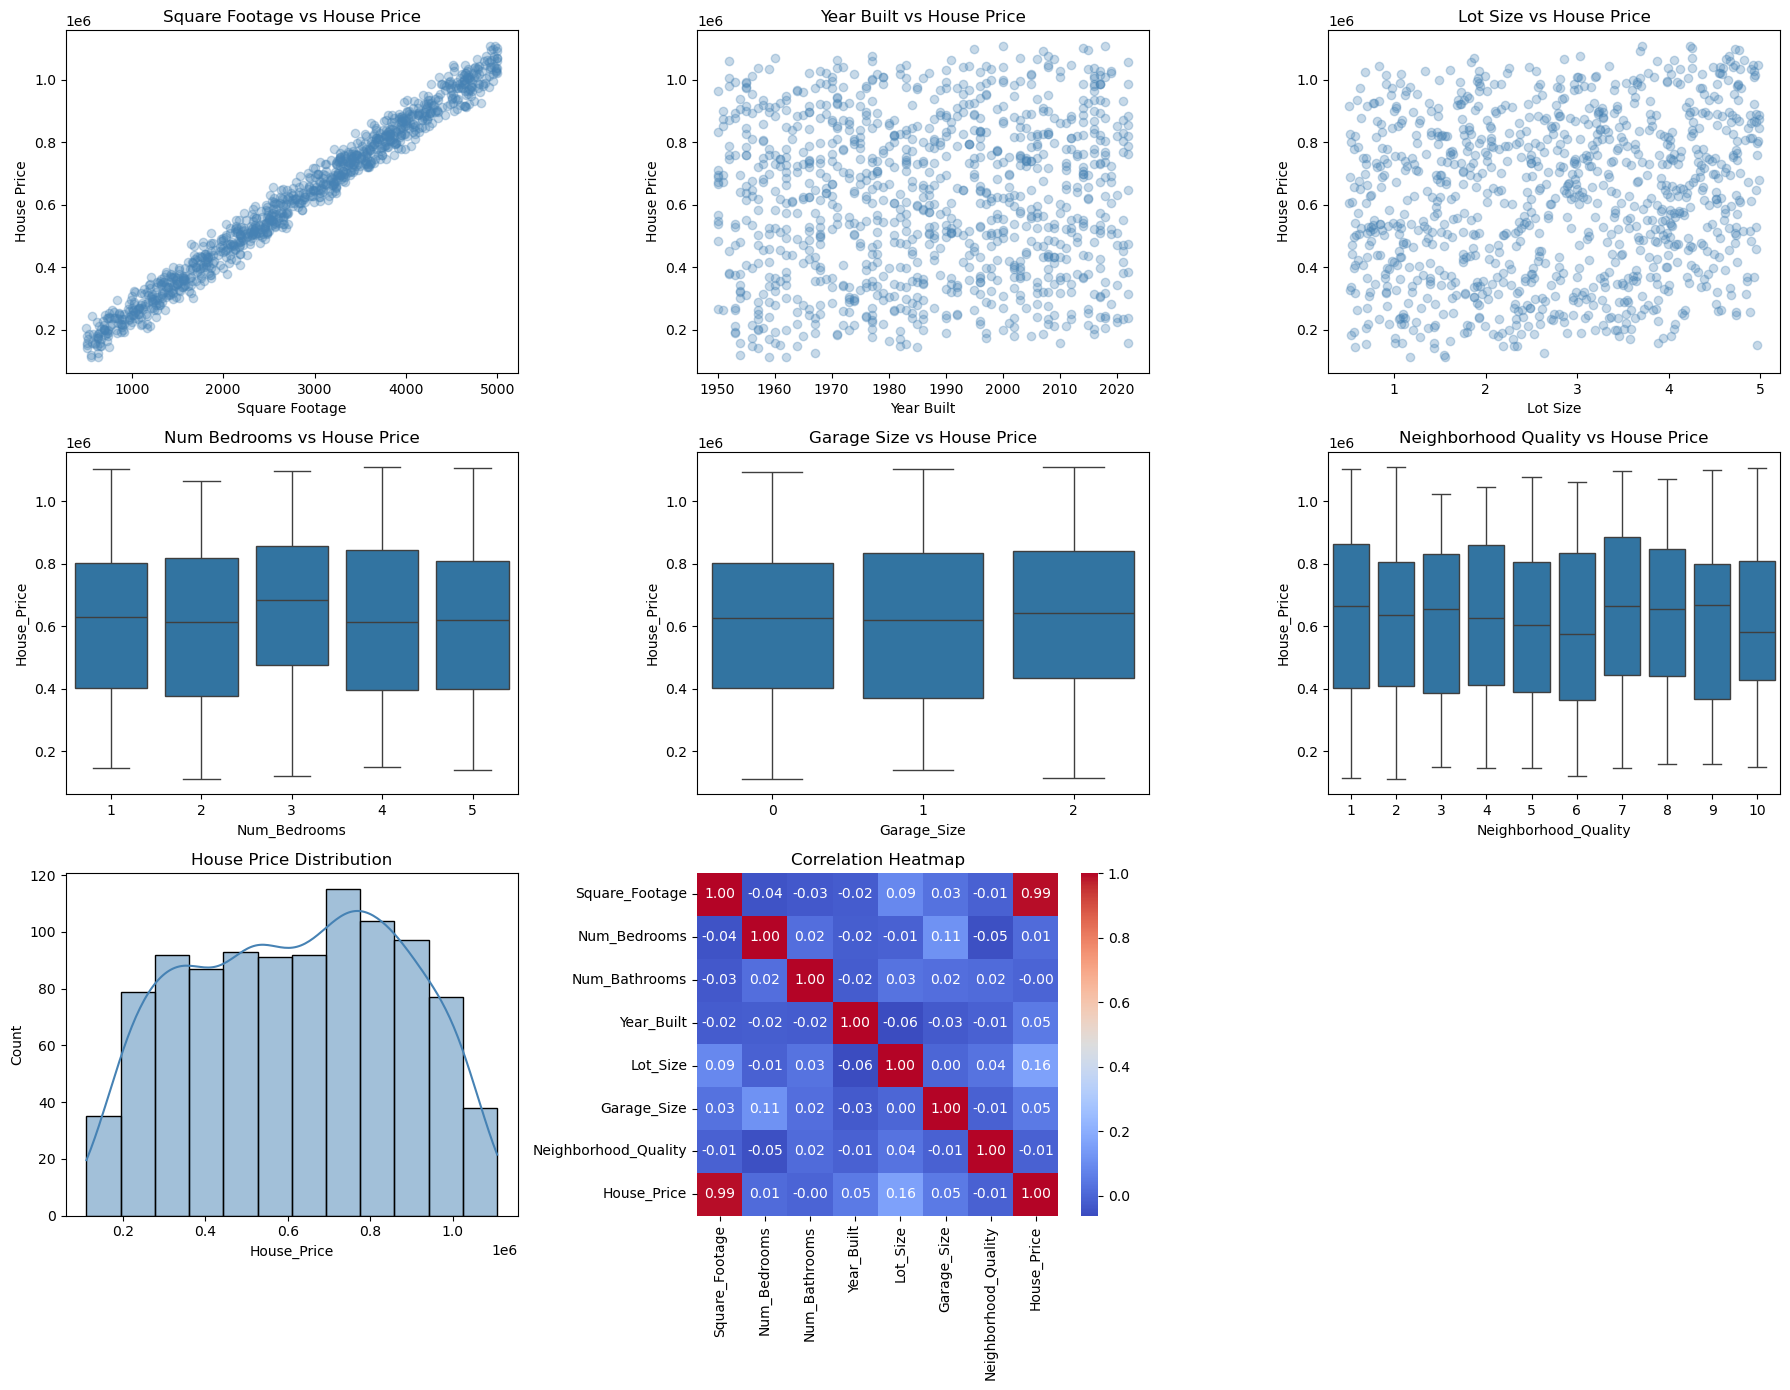

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# 1. Square_Footage vs House_Price
axes[0,0].scatter(df['Square_Footage'], df['House_Price'], alpha=0.3, color='steelblue')
axes[0,0].set_title("Square Footage vs House Price")
axes[0,0].set_xlabel("Square Footage")
axes[0,0].set_ylabel("House Price")

# 2. Year_Built vs House_Price
axes[0,1].scatter(df['Year_Built'], df['House_Price'], alpha=0.3, color='steelblue')
axes[0,1].set_title("Year Built vs House Price")
axes[0,1].set_xlabel("Year Built")
axes[0,1].set_ylabel("House Price")

# 3. Lot_Size vs House_Price
axes[0,2].scatter(df['Lot_Size'], df['House_Price'], alpha=0.3, color='steelblue')
axes[0,2].set_title("Lot Size vs House Price")
axes[0,2].set_xlabel("Lot Size")
axes[0,2].set_ylabel("House Price")

# 4. Num_Bedrooms vs House_Price (boxplot)
sns.boxplot(data=df, x='Num_Bedrooms', y='House_Price', ax=axes[1,0])
axes[1,0].set_title("Num Bedrooms vs House Price")

# 5. Garage_Size vs House_Price (boxplot)
sns.boxplot(data=df, x='Garage_Size', y='House_Price', ax=axes[1,1])
axes[1,1].set_title("Garage Size vs House Price")

# 6. Neighborhood_Quality vs House_Price (boxplot)
sns.boxplot(data=df, x='Neighborhood_Quality', y='House_Price', ax=axes[1,2])
axes[1,2].set_title("Neighborhood Quality vs House Price")

# 7. House_Price Distribution
sns.histplot(df['House_Price'], kde=True, ax=axes[2,0], color='steelblue')
axes[2,0].set_title("House Price Distribution")

# 8. Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', ax=axes[2,1])
axes[2,1].set_title("Correlation Heatmap")

axes[2,2].set_visible(False)

plt.tight_layout()
plt.show()

## EDA Results

- Square_Footage dominates house price with a correlation of 0.99.
- Other numerical variables (Year_Built, Lot_Size, Num_Bedrooms,
  Garage_Size, Neighborhood_Quality) show weak correlation with 
  price (max 0.16).
- House_Price has a uniform distribution with no significant outliers.
- No categorical variables found, encoding will not be required.
- Building_Age and Price_per_sqft will be derived in feature engineering.